# **Segmentación de Ambientes Agroclimáticos Críticos para Cultivo de Maíz en la Provincia del Guayas (2015-2025)**

Este pipeline presenta una arquitectura modular que procesa 11 años de datos históricos satelitales (2015-2025). Su objetivo es transformar registros climáticos crudos en variables de decisión agronómica de alta precisión, permitiendo modelar el comportamiento del cultivo de maíz (*Zea mays*) frente a la variabilidad climática de la provincia del Guayas.

Datos: **NASA POWER**

 **Objetivos**
* **Segmentación:** Dividir los 11 años en grupos con lógica estadística.

* **Ambientes críticos para el maíz:** Identificar cuándo el clima se vuelve peligroso (Sequía o Inundación).

* **Temporalidad:** Analizar una década completa para ver tendencias.

In [29]:
# Importamos las librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [30]:
# Importamos los datos históricos del clima
data = pd.read_csv('HISTORIAL_CLIMATOLÓGICO_10_AÑOS_FECHAS.csv', sep=";")

In [31]:
data.shape # Verificamos las dimensiones de entrada del dataset (filas, columnas)

(4018, 12)

In [32]:
# Inspeccionamos los primeros 5 registros del dataset
data.head()

,DATE,ALLSKY_SFC_SW_DWN,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,IMERG_PRECTOT,WSC,WS2M,GWETTOP,PS
0,1/1/2015,10.72,29.53,38.70,23.71,58.81,0.57,0.11,3.04,3.07,0.26,100.06
1,2/1/2015,14.43,29.29,38.44,23.58,59.69,0.55,0.00,3.37,3.43,0.27,100.04
2,3/1/2015,14.37,29.24,37.73,23.55,58.10,1.20,2.96,3.36,3.36,0.27,100.01
3,4/1/2015,10.64,28.79,36.98,23.29,60.36,4.35,0.88,3.46,3.38,0.43,100.15
4,5/1/2015,14.78,29.36,37.99,23.39,58.16,0.19,0.07,2.71,2.69,0.41,100.15


In [33]:
# Verificamos el contenido y formato de las variables con .info()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DATE               4018 non-null   object 
 1   ALLSKY_SFC_SW_DWN  4018 non-null   float64
 2   T2M                4018 non-null   float64
 3   T2M_MAX            4018 non-null   float64
 4   T2M_MIN            4018 non-null   float64
 5   RH2M               4018 non-null   float64
 6   PRECTOTCORR        4018 non-null   float64
 7   IMERG_PRECTOT      4018 non-null   float64
 8   WSC                4018 non-null   float64
 9   WS2M               4018 non-null   float64
 10  GWETTOP            4018 non-null   float64
 11  PS                 4018 non-null   float64
dtypes: float64(11), object(1)
memory usage: 376.8+ KB


# **Pre-procesamiento y Estructuración (ETL)**

In [34]:
# Eliminamos la temperatura media
data.drop('T2M',axis=1, inplace=True)

**Importante:** Debemos calcular manualmente la temperatura media; esto reduciría el sesgo en el cluster, ya que al usar la temperatura del satélite, haría que la ETo fuera tan baja que el balance hídrico parecía positivo incluso en meses secos.

No podemos lanzar el modelo sobre fechas desordenadas. Primero, prepararemos el **esqueleto** del dataset.

In [35]:
#Renombramos las columnas del DataFrame
data.rename(columns={
    'DATE':'fecha','T2M':'temp_media', 'T2M_MAX':'temp_max', 'T2M_MIN':'temp_min',
    'ALLSKY_SFC_SW_DWN':'radiacion',  'WS2M':'viento','PRECTOTCORR':'lluvia','IMERG_PRECTOT':'lluvia_imerg','RH2M':'humedad', 'GWETTOP':'hum_suelo', 'PS':'presion', 'WSC':'vel_viento'
}, inplace=True)

In [36]:
# Verificamos las columnas renombradas
data.columns

Index(['fecha', 'radiacion', 'temp_max', 'temp_min', 'humedad', 'lluvia',
       'lluvia_imerg', 'vel_viento', 'viento', 'hum_suelo', 'presion'],
      dtype='object')

In [37]:
# Establecemos la fecha cono índice de nuestro dataset
data.set_index('fecha', inplace=True)

# Convertir el índice actual es texto de Excel a objetos de tiempo reales  datetime64[ns]
data.index = pd.to_datetime(data.index, dayfirst=True, utc=True) #Especificamos el estándar del horario global UTC

# Ordenar cronológicamente (vital para que los promedios móviles no den basura)
data.sort_index(inplace=True)

# Verificar el cambio
print(data.index.dtype) # Ahora debe decir datetime64[ns]

datetime64[ns, UTC]


In [38]:
data.head()

,radiacion,temp_max,temp_min,humedad,lluvia,lluvia_imerg,vel_viento,viento,hum_suelo,presion
fecha,,,,,,,,,,
2015-01-01 00:00:00+00:00,10.72,38.70,23.71,58.81,0.57,0.11,3.04,3.07,0.26,100.06
2015-01-02 00:00:00+00:00,14.43,38.44,23.58,59.69,0.55,0.00,3.37,3.43,0.27,100.04
2015-01-03 00:00:00+00:00,14.37,37.73,23.55,58.10,1.20,2.96,3.36,3.36,0.27,100.01
2015-01-04 00:00:00+00:00,10.64,36.98,23.29,60.36,4.35,0.88,3.46,3.38,0.43,100.15
2015-01-05 00:00:00+00:00,14.78,37.99,23.39,58.16,0.19,0.07,2.71,2.69,0.41,100.15


Para confirmar que todo está bien, un gráfico rápido que compare la Temperatura Máxima y la Lluvia. Esto permitirá ver visualmente si hay algún outlier (un valor exagerado por ejemplo 100°C o semejante).

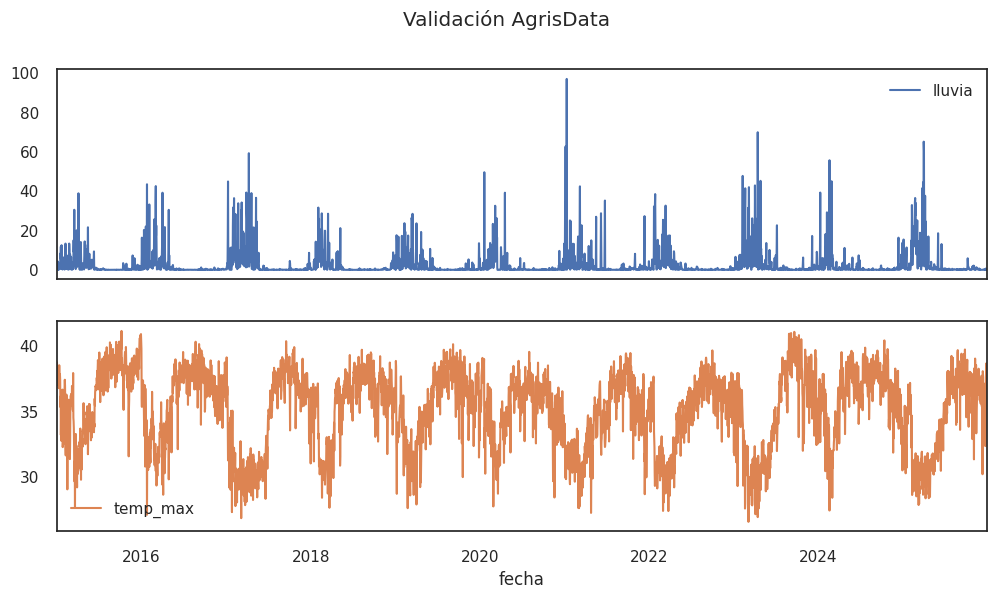

In [39]:
data[['lluvia','temp_max']].plot(subplots=True, figsize=(12, 6), title="Validación AgrisData")
plt.show()

#**Cálculo de Variables Agroclimáticas**

Al calcular la ETo y el balance hídrico, sepodrá identificar qué meses del registro histórico (2015-2025) fueron realmente críticos. Un balance negativo sostenido por más de 10 días es un indicador de estrés que el K-Means detectará de inmediato.

Método de cálculo de ETo para este análisis es **Hargreaves-Samani (1985)**


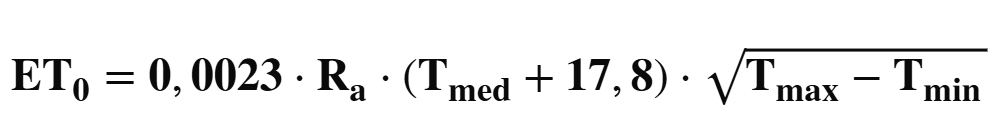


In [40]:
# 1. DELTA TÉRMICO, TEMPERATURA MEDIA Y GDD
#Unicamente energía que el cultivo aprovecha
data['temp_media'] = (data['temp_max'] + data['temp_min'])/2 # Cálculo manual para recuperar la amplitud térmica real del Guayas
data['delta_t'] = data['temp_max'] - data['temp_min'] # Delta Térmico (Importante para el llenado de grano)
data['gdd'] = ((data['temp_max'] + data['temp_min']) / 2 - 10).clip(lower=0) #GDD (Grados Día Calor) - Umbral Maíz: 10°C

# 2. EVAPOTRANSPIRACIÓN POTENCIAL (ETo) - Método Hargreaves-Samani
# Usamos la radiación (MJ/m²/día) convertida a mm con el factor 0.408
# La fórmula integra energía solar y la oscilación térmica como motor de evaporación.
data['eto'] = 0.0023 * (0.408 * data['radiacion']) * (data['temp_media'] + 17.8) * np.sqrt(data['delta_t'])

# 3. BALANCE HÍDRICO Y ACUMULADOS
data['bal_hidrico'] = data['lluvia'] - data['eto']
data['lluvia_acum_15d'] = data['lluvia'].rolling(window=15).sum() # Lluvia Acumulada (Memoria hídrica de 15 días), mide la reserva de agua.

# 4. LIMPIEZA FINAL
data.dropna(inplace=True)

print("Variables agroclimáticas consolidadas.")
print(data[['gdd', 'eto', 'bal_hidrico']].tail().round(3))

Variables agroclimáticas consolidadas.
                              gdd    eto  bal_hidrico
fecha                                                
2025-12-27 00:00:00+00:00  19.450  2.752       -2.052
2025-12-28 00:00:00+00:00  19.210  2.729       -2.349
2025-12-29 00:00:00+00:00  19.835  2.972       -2.952
2025-12-30 00:00:00+00:00  19.645  1.600       -1.500
2025-12-31 00:00:00+00:00  20.140  2.503       -2.443


Verificamos que los valores calculados tengan coherencia agronómica.

* **GDD:** Debería estar en un rango de 10 a 18 (para el clima del Guayas). Si se evidencia un 500 o  -5, el cálculo falló.

* **ETo:** Debería oscilar entre 3 mm y 7 mm diarios. En caso de presentar 0 o 100, la fórmula de Hargreaves tiene un error de unidades.

* **Balance Hídrico:** Verificamos que sea la resta lógica entre lluvia y evaporación.

#**Modelo K-Means**

**Preparación para el Clustering (K-Means)**

Antes de lanzar el algoritmo, hay que tener presente que K-Means es sensible a las escalas (por ejemplo, la lluvia puede ser de 0 a 100, mientras que el GDD es de 5 a 15).

¿Cómo procederemos?

* **Normalización:** Usaremos StandardScaler para que todas tengan el mismo peso estadístico.

* **Selección de Features:** Para el clustering, es sugerible usar: ['gdd', 'delta_t', 'eto, 'lluvia_acum_15d', 'hum_suelo','bal_hidrico']. Esta combinación separa perfectamente los **ambientes** de cultivo.

In [41]:
# Importamos librería para escalar las variables X
from sklearn.preprocessing import StandardScaler

# 1. Seleccionamos las variables agroclimáticas clave para el modelo
variables = ['gdd', 'delta_t', 'eto', 'lluvia_acum_15d','hum_suelo','bal_hidrico']
X = data[variables]

# 2. Estandarización (Media = 0, Desviación Estándar = 1)
ss = StandardScaler()
X_escalado = ss.fit_transform(X)

Para el clustering que haremos, estas variables separan el dataset en dimensiones físicas reales:

* **GDD y Delta T** definen la energía térmica.

* **Húmedad del suelo y Lluvia Acumulada 15 días** define la disponibilidad de agua.

* **Eto** define la demanda atmosférica.

Ahora hay que decidir cuántos grupos (clusters) existen en la zona del Guayas. **No podemos adivinar**. Usaremos el Método del Codo (Elbow Method) para ver dónde la inercia del modelo deja de caer drásticamente.

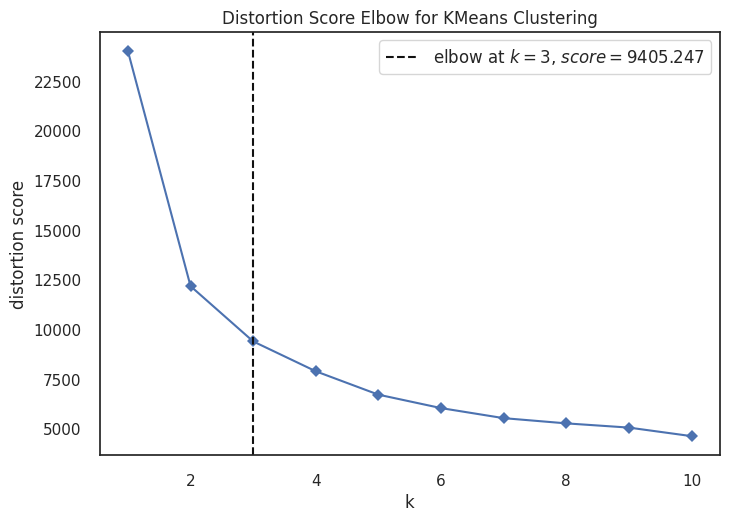

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [42]:
from yellowbrick.cluster import KElbowVisualizer

# Configuramos el modelo y el visualizador
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(1,11), timings=False)

visualizer.fit(X_escalado)      # Entrena y grafica
visualizer.show()               # Muestra el "codo" exacto

In [43]:
# 1. Entrenamos el modelo con k=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_escalado)

# 2. Verificamos cuántos días cayeron en cada categoría
print("Distribución de días por cluster:")
print(data['cluster'].value_counts())

# 3. Análisis de Perfiles (La parte "Exquisita")
# Agrupamos por cluster para ver el promedio de cada variable y entender qué es cada grupo
perfil_clusters = data.groupby('cluster')[variables].mean()
print("\nPerfil promedio de cada Cluster:")
print(perfil_clusters)

Distribución de días por cluster:
cluster
1    2155
2    1254
0     595
Name: count, dtype: int64

Perfil promedio de cada Cluster:
               gdd    delta_t       eto  lluvia_acum_15d  hum_suelo  \
cluster                                                               
0        16.827672   7.161966  1.555808       147.944017   0.850639   
1        19.667123  15.184603  2.453533         5.625777   0.284510   
2        18.100586  10.973198  1.862055        40.183110   0.624187   

         bal_hidrico  
cluster               
0          10.048125  
1          -2.187162  
2           0.173351  


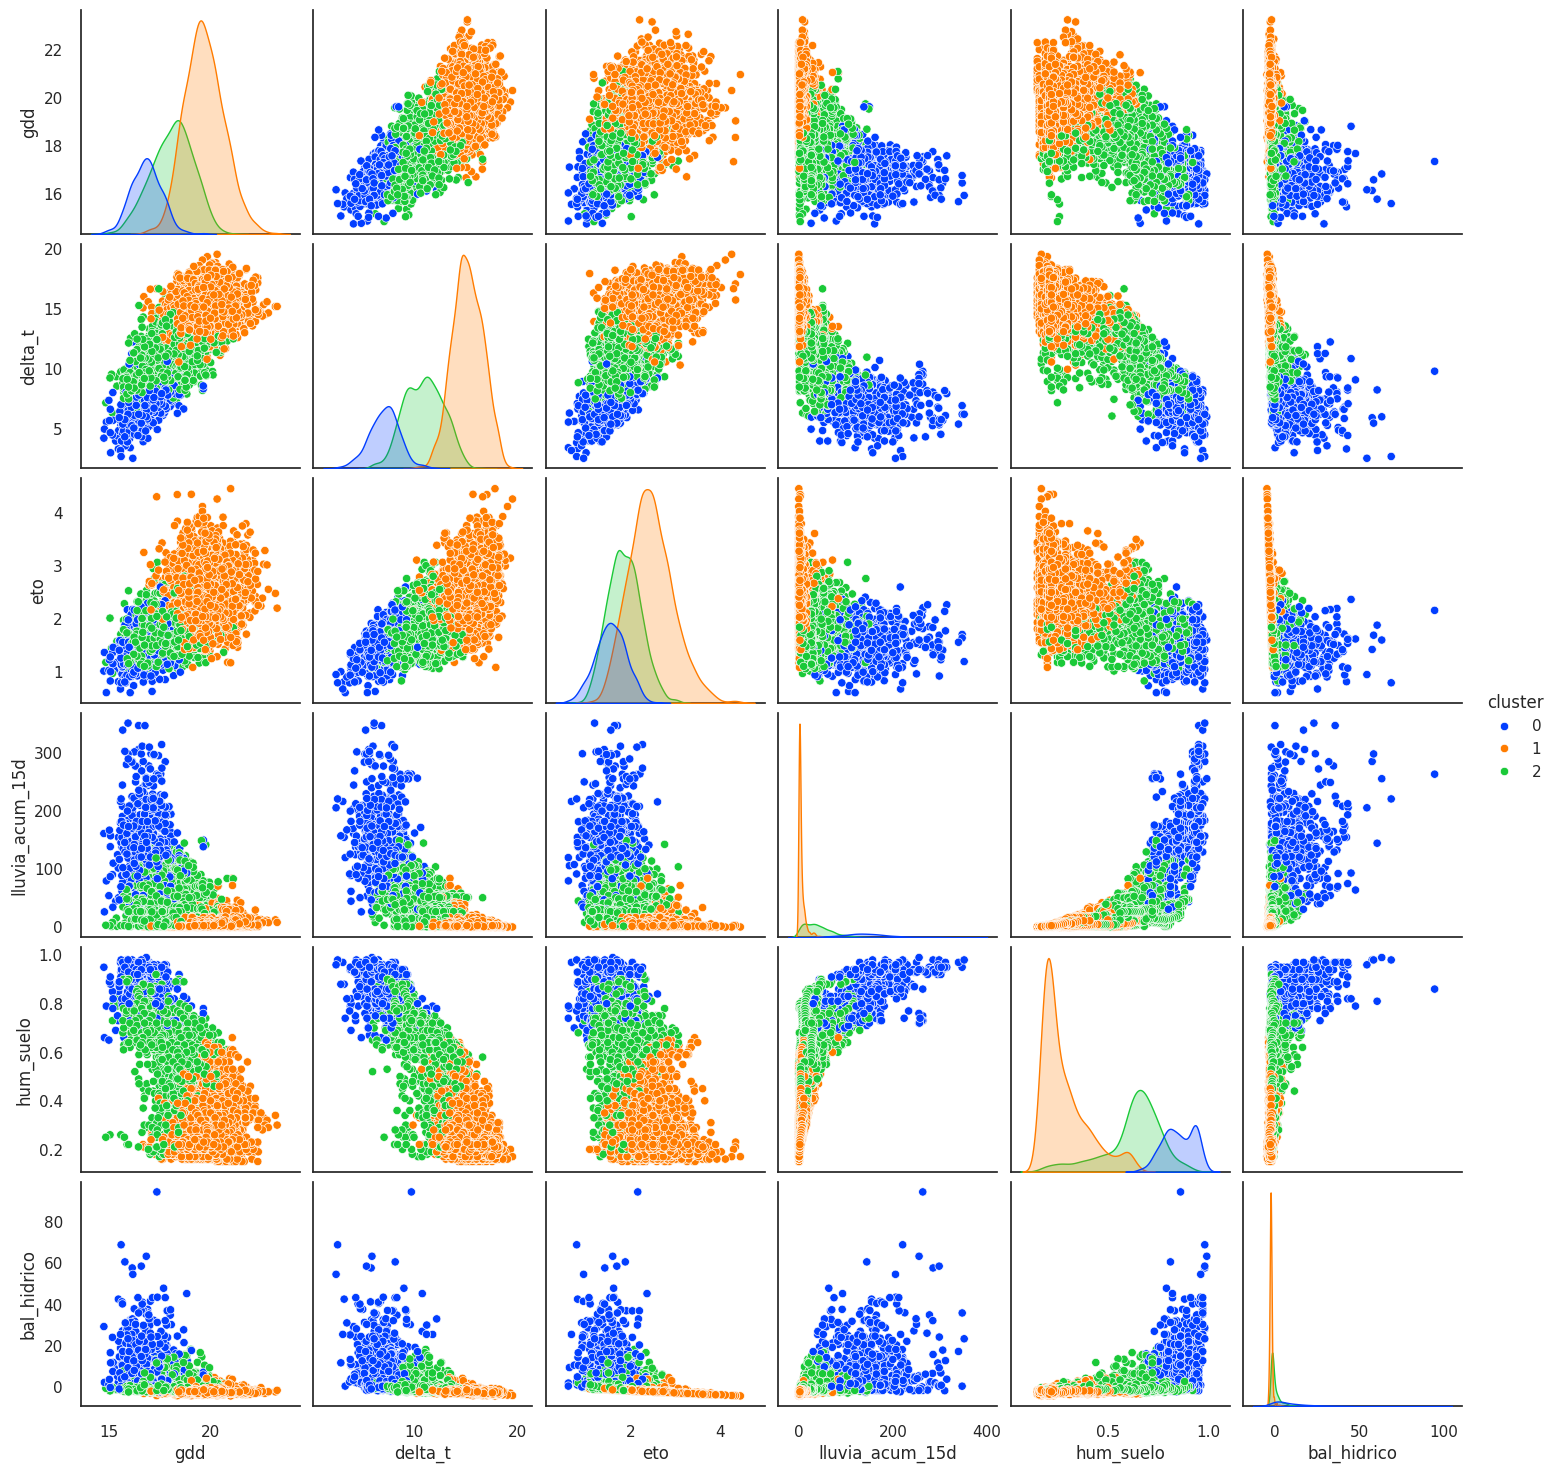

In [44]:
# Con seaborn creamos una vista rápida de cómo se separan los clusters
sns.pairplot(data[variables + ['cluster']], hue='cluster', palette='bright', diag_kind='kde')
plt.show()

**Interpretación de los Clusters**
* **Cluster 1 (Verano / Déficit Hídrico)**: Es el más frecuente (2,155 días). Tiene el GDD más alto (19.67) y el Delta T más fuerte (15.18°C), pero una humedad de suelo crítica (0.28). Es el escenario de máxima demanda evaporativa y nula reserva hídrica con balance hídrico negativo (-2.18), el cultivo agota sus reservas.

* **Cluster 0 (Invierno / Saturación)**: El menos frecuente (595 días). Se define por la lluvia acumulada extrema (147.94 mm en 15 días) y una humedad de suelo cercana a la saturación (0.85). Aquí el Delta T cae a 7.2°C, típico de días nublados y lluviosos. El balance hídrico se dispara a 10.04

* **Cluster 2 (Transición / Óptimo):** Con 1,254 días, presenta un equilibrio. Humedad de suelo moderada (0.62) y acumulados de lluvia manejables (40.18 mm). Es el ambiente donde el maíz suele encontrar su zona de confort en la zona. El balance hídrico es ligeramente positivo (0.17)

**Visualización del Espacio de Estados (Scatter Plot)**
Para validar que los clusters no se solapan de forma caótica, lo más profesional es graficar la Humedad del Suelo vs. GDD. Esto nos mostrará cómo la energía térmica se separa según la disponibilidad de agua.

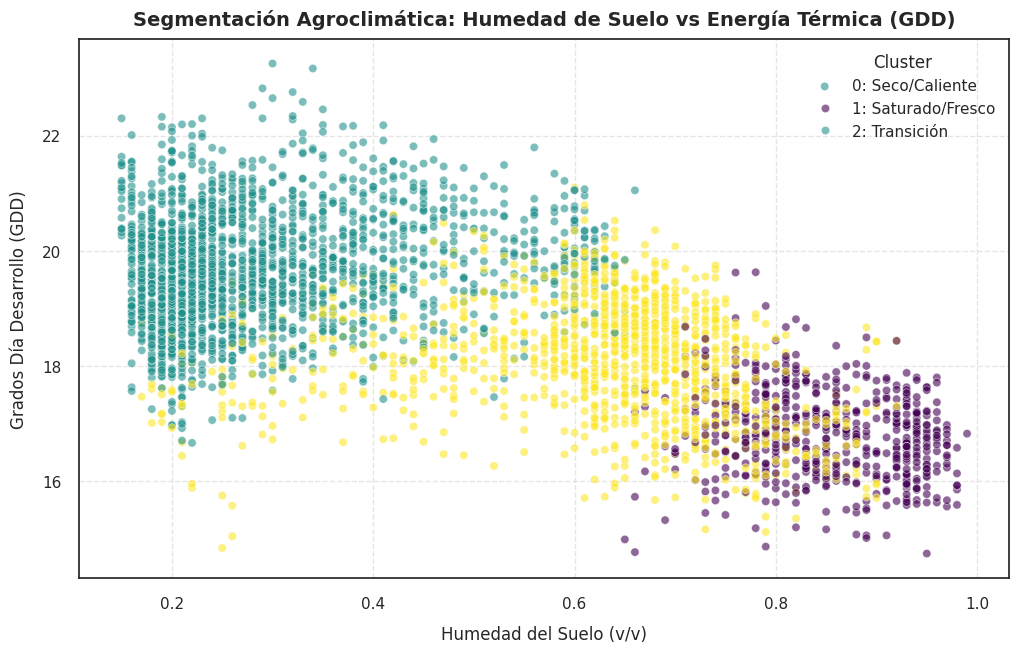

In [45]:
plt.figure(figsize=(12, 7))

# Graficamos la relación Humedad de Suelo vs GDD, coloreando por Cluster
sns.scatterplot(data=data, x='hum_suelo', y='gdd', hue='cluster', palette='viridis', alpha=0.6)

plt.title('Segmentación Agroclimática: Humedad de Suelo vs Energía Térmica (GDD)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Humedad del Suelo (v/v)', labelpad=10)
plt.ylabel('Grados Día Desarrollo (GDD)',labelpad=10)
plt.legend(title='Cluster', labels=['0: Seco/Caliente', '1: Saturado/Fresco', '2: Transición'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Como ya cada día tiene un número, ahora queremos saber cuántos días seguidos se queda el clima en el grupo de "Sequía".

In [46]:
# 1. Crear una marca para los días de sequía
data['es_sequia'] = (data['cluster'] == 0).astype(int)

# 2. ne() detecta el cambio y cumsum() crea el ID del grupo
bloques = data['es_sequia'].ne(data['es_sequia'].shift()).cumsum()

# 3. Identificamos si el día pertenece al Cluster 0 (Seco/Cálido)
data['es_estres'] = (data['cluster'] == 0).astype(int)

# 4. Lógica de agrupamiento de rachas consecutivas
# Comparamos el valor actual con el anterior para detectar cambios de estado
data['cambio_estado'] = data['es_estres'].ne(data['es_estres'].shift()).cumsum()

# 5. Calculamos la duración de cada racha de Cluster 0
rachas = data[data['es_estres'] == 1].groupby('cambio_estado').size()

# 6. Estadísticos de las rachas
print(f"Número total de rachas de estrés detectadas: {len(rachas)}")
print(f"Duración máxima de una racha de estrés: {rachas.max()} días")
print(f"Duración promedio de las rachas: {rachas.mean():.2f} días")

# 7. Top 5 de las rachas más largas (¿Cuándo ocurrieron?)
top_rachas = rachas.sort_values(ascending=False).head(5)
print("\nTop 5 Rachas más críticas (Duración en días):")
print(top_rachas)

Número total de rachas de estrés detectadas: 104
Duración máxima de una racha de estrés: 113 días
Duración promedio de las rachas: 5.72 días

Top 5 Rachas más críticas (Duración en días):
cambio_estado
54     113
202     68
166     35
162     34
60      29
dtype: int64


Ahora determinaremos las fechas exactas de esas rachas críticas. Esto te servirá para identificar qué años fueron los más duros para el cultivo en la zona del Guayas.

In [47]:
# 1. Identificar cuándo empiezan y terminan las rachas del Cluster 0
rachas_info = data[data['es_sequia'] == 1].groupby(bloques).agg(
    fecha_inicio=('lluvia', lambda x: x.index.min()),
    fecha_fin=('lluvia', lambda x: x.index.max()),
    duracion_dias=('es_sequia', 'count')
)

# 2. Ver las 3 rachas más largas de la historia
top_3_sequias = rachas_info.sort_values(by='duracion_dias', ascending=False).head(3)

print("LAS 3 PEORES RACHAS DE SEQUÍA (2015-2025):")
print(top_3_sequias)

LAS 3 PEORES RACHAS DE SEQUÍA (2015-2025):
                       fecha_inicio                 fecha_fin  duracion_dias
es_sequia                                                                   
54        2017-01-30 00:00:00+00:00 2017-05-22 00:00:00+00:00            113
202       2025-02-10 00:00:00+00:00 2025-04-18 00:00:00+00:00             68
166       2023-03-30 00:00:00+00:00 2023-05-03 00:00:00+00:00             35


In [48]:
data

,radiacion,temp_max,temp_min,humedad,lluvia,lluvia_imerg,vel_viento,viento,hum_suelo,presion,temp_media,delta_t,gdd,eto,bal_hidrico,lluvia_acum_15d,cluster,es_sequia,es_estres,cambio_estado
fecha,,,,,,,,,,,,,,,,,,,,
2015-01-15 00:00:00+00:00,15.99,37.38,23.51,60.14,2.15,0.00,2.80,2.73,0.43,100.23,30.445,13.87,20.445,2.696044,-0.546044,15.10,1,0,0,1
2015-01-16 00:00:00+00:00,11.22,35.30,23.61,63.83,8.29,0.00,3.54,3.34,0.47,100.35,29.455,11.69,19.455,1.701124,6.588876,22.82,2,0,0,1
2015-01-17 00:00:00+00:00,17.55,36.11,22.65,69.10,5.70,32.76,2.73,2.57,0.63,100.35,29.380,13.46,19.380,2.850661,2.849339,27.97,1,0,0,1
2015-01-18 00:00:00+00:00,9.77,33.17,22.35,73.86,11.77,30.97,2.69,2.41,0.69,100.47,27.760,10.82,17.760,1.373978,10.396022,38.54,2,0,0,1
2015-01-19 00:00:00+00:00,14.66,34.63,22.94,69.47,2.03,0.00,2.36,1.95,0.61,100.40,28.785,11.69,18.785,2.191166,-0.161166,36.22,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 00:00:00+00:00,17.15,36.00,22.90,57.26,0.70,0.00,3.52,3.53,0.21,100.25,29.450,13.10,19.450,2.752261,-2.052261,2.35,1,0,0,209
2025-12-28 00:00:00+00:00,15.91,36.77,21.65,58.18,0.38,0.00,3.50,3.47,0.24,100.24,29.210,15.12,19.210,2.729131,-2.349131,2.70,1,0,0,209
2025-12-29 00:00:00+00:00,15.85,38.63,21.04,56.45,0.02,0.00,3.11,3.10,0.23,100.16,29.835,17.59,19.835,2.971504,-2.951504,2.61,1,0,0,209


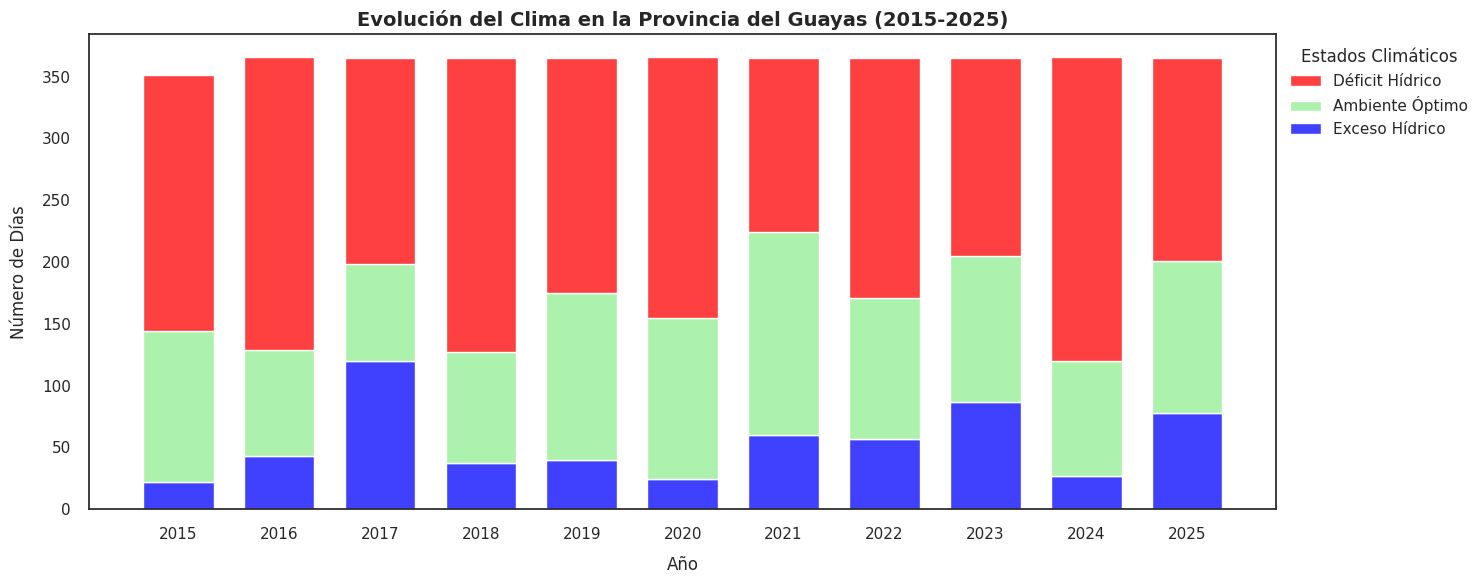

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mapeamos los nombres una sola vez en el DataFrame principal
clusteres = {0:'Exceso Hídrico',1:'Déficit Hídrico', 2:'Ambiente Óptimo'}
data['Estado'] = data['cluster'].map(clusteres)

# 2. Configuración estética rápida
plt.figure(figsize=(15, 6))
sns.set_theme(style='white')
colores = ['red','lightgreen','blue']

# 3. El gráfico: Seaborn se encarga de agrupar y contar por ti
sns.histplot(data=data, x=data.index.year, hue='Estado',
            multiple='stack', palette=colores, shrink=0.7, discrete=True)

# 4. Ajustes finales
plt.title('Evolución del Clima en la Provincia del Guayas (2015-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12, labelpad=10)
plt.ylabel('Número de Días', fontsize=12, labelpad=10)
plt.xticks(range(2015, 2026))

# Mover la leyenda fuera (Seaborn la crea automáticamente con los nombres de 'Estado')
sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1), title='Estados Climáticos')

plt.tight_layout()
plt.show()

**¿Qué dice este gráfico?**
* **Rojo (C0):** Si las barras rojas crecen cada año, la zona se está volviendo más árida.

* **Azul (C1):** Representa los años con inviernos más agresivos o eventos tipo "El Niño".

* **Verde (C2):** Es la "ventana de éxito". Entre más verde tenga un año, mejores fueron las condiciones para el maíz.

Ahora calculamos procentualmente que clima manda en la zona del Guayas

In [50]:
# 1. Calcular el porcentaje de cada cluster
porcentajes = data['cluster'].value_counts(normalize=True) * 100

# 2. Mostrar los resultados de forma clara
print("¿Quién manda en el clima del Guayas?")
print(f"Estado Seco (C-1): {porcentajes[1]:.1f}% de los días")
print(f"Estado Óptimo (C-2): {porcentajes[2]:.1f}% de los días")
print(f"Estado Lluvioso (C-0): {porcentajes[0]:.1f}% de los días")

¿Quién manda en el clima del Guayas?
Estado Seco (C-1): 53.8% de los días
Estado Óptimo (C-2): 31.3% de los días
Estado Lluvioso (C-0): 14.9% de los días


**Interpretación Agrónomica:**

Esto demuestra que más del 50% del tiempo el clima es seco, cualquier herramienta que ayude a gestionar el riego o predecir estas rachas es oro puro para los agricultores.

In [51]:
# 1. Identificar automáticamente cuál es el número del cluster más seco
cluster_seco = data.groupby('cluster')['lluvia_acum_15d'].mean().idxmin()

# 2. Calcular las probabilidades
data['mes'] = data.index.month
probabilidad_mes = data.groupby('mes')['cluster'].value_counts(normalize=True).unstack() * 100

# 3. Imprimir la probabilidad del cluster identificado como seco
print(f"Probabilidad de Sequía (Cluster {cluster_seco}) por mes:")
print(probabilidad_mes[cluster_seco].fillna(0).round(1))

Probabilidad de Sequía (Cluster 1) por mes:
mes
1     28.4
2      4.2
3      2.9
4      9.7
5     24.6
6     45.8
7     79.2
8     97.7
9     99.1
10    92.4
11    89.1
12    68.3
Name: 1, dtype: float64


**Resumen del análisis agroclimático:**
* **De Junio a Noviembre:** Es la "Zona Roja". El Cluster 1 (Seco) domina casi el 90% del tiempo. Riesgo máximo.

* **De Enero a Abril:** Es la "Zona Azul". El Cluster 0 (Lluvias) y el Cluster 2 (Óptimo) se reparten los días. Es tu ventana de siembra.

* **Mayo y Diciembre:** Son meses de cambio. El clima
"salta" de un estado a otro.

**Conclusión:** La aplicación de aprendizaje no supervisado sobre la serie histórica decenal identifica una estructura climática tripartita en la provincia del Guayas, donde el Estado de Déficit Hídrico (Cluster 1) es la condición prevalente, abarcando más del 50% del registro temporal. Los resultados demuestran que la variabilidad interanual no es uniforme, sino que se manifiesta a través de rachas secas prolongadas que contrastan con eventos de saturación extrema (Cluster 0), reduciendo significativamente los periodos de estabilidad termo-hídrica (Cluster 2). Esta caracterización permite establecer umbrales críticos de la variabilidad climática estacional en un factor de riesgo cuantificable para la rentabilidad del cultivo de maíz.